Implement cost function idea( 2D and 3D )...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [28]:
x_train = np.array([1.0,2.0])
y_train = np.array([300.0, 500.0])
w = 0
b = 0

In [29]:
def cost_function_compute(x, y, w, b):
    m = x.shape[0]
    J_wb_temp = np.zeros(m)

    for i in range(m):
        J_wb_temp[i] = (w * x[i] + b - y[i]) ** 2

    J_wb = np.mean(J_wb_temp) / 2

    return J_wb

In [30]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w*x[i]+b

    return f_wb

In [31]:
def plt_intuition(x, y):

    # Initial value of w
    w_initial = 100

    # Create figure with two plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # LEFT: Training data + line
    # -------------------------

    f_wb = compute_model_output(x, w_initial, b)

    line, = ax1.plot(
        x,
        f_wb,
        c="b",
        label="Our Prediction"
    )

    ax1.scatter(
        x,
        y,
        marker="x",
        c="r",
        label="Actual Values"
    )

    ax1.set_xlabel("size in feet²")
    ax1.set_ylabel("price in $1000's")
    ax1.set_title("House sizes and prices")
    ax1.legend()

    # -------------------------
    # RIGHT: Cost vs w
    # -------------------------

    w_values = np.linspace(-100, 600, 300)

    cost_values = []

    for w_value in w_values:
        cost_values.append(
            cost_function_compute(x, y, w_value, b)
        )

    ax2.plot(
        w_values,
        cost_values,
        c="g",
        label="Cost J(w)"
    )

    ax2.set_xlabel("w")
    ax2.set_ylabel("J(w)")
    ax2.set_title("Cost Function")

    # Current position of w
    current_cost = cost_function_compute(
        x,
        y,
        w_initial,
        b
    )

    point, = ax2.plot(
        w_initial,
        current_cost,
        "ro"
    )

    ax2.legend()

    # -------------------------
    # SLIDER
    # -------------------------

    slider_ax = fig.add_axes([0.20, 0.02, 0.60, 0.03])

    w_slider = Slider(
        ax=slider_ax,
        label="w",
        valmin=-100,
        valmax=600,
        valinit=w_initial,
        valstep=1
    )

    # -------------------------
    # UPDATE FUNCTION
    # -------------------------

    def update(val):

        w = w_slider.val

        # Update prediction line
        new_f_wb = compute_model_output(
            x,
            w,
            b
        )

        line.set_ydata(new_f_wb)

        # Calculate new cost
        new_cost = cost_function_compute(
            x,
            y,
            w,
            b
        )

        # Move point on cost curve
        point.set_data([w], [new_cost])

        fig.canvas.draw_idle()

    # Connect slider to update function
    w_slider.on_changed(update)

    plt.show()

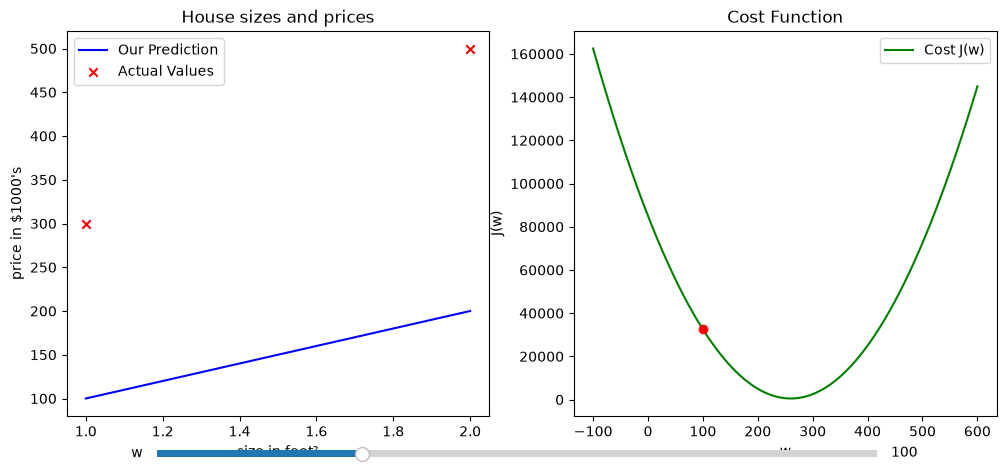

In [32]:
plt_intuition(x_train,y_train)